### Cross-validation showed that models 226, 262, 298, 227, 263, 299, 223 have good generalization ability

The whole data-processing pipeline was rewritten as a class; now we examine the selected top models. For each model, the loss history and the target metric history are plotted on one figure.

In [ ]:
import pandas as pd
import numpy as np
from data_preprocessing import DataProcessing
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    balanced_accuracy_score, 
    log_loss, hinge_loss
)
from log_parser import find_best_models, param_parser_by_num
from sklearn.model_selection import train_test_split

import os
import logging
from datetime import datetime

FileName = "logs_log_reg/big_training_log_20260723_230607.log"
amount_of_best_models = 10

num_of_best_models = [x[0] for x in find_best_models(FileName, amount_of_best_models)]
params = param_parser_by_num(FileName, num_of_best_models)
print(num_of_best_models)
print(params)

model_numbers = [226, 262, 298, 227, 263, 299, 223] # selected best models
amount_of_best_models = len(model_numbers)
FINAL_BEST_MODELS = {num: params[num] for num in model_numbers}

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(message)s',
    handlers=[
        logging.StreamHandler()
    ],
    force=True 
)

df = pd.read_csv("datasets/train.csv")
y = df["health_condition"]
train_df, val_df = train_test_split(df, test_size=0.2, 
                                     random_state=42, stratify=y)

                               
train_data_prep = DataProcessing(train_df, data_type="train")
val_data_prep =  DataProcessing(val_df, data_type="train")
test_data_prep = DataProcessing(pd.read_csv("datasets/test.csv"), data_type="test")

train_df = train_data_prep.df_prepr()
X_train = train_df.drop(columns=["health_condition"])
y_train = train_df["health_condition"]

val_data_prep.median = train_data_prep.median
val_data_prep.encoder = train_data_prep.encoder
val_data_prep.scaler = train_data_prep.scaler
val_df = val_data_prep.df_prepr()
X_val = val_df.drop(columns=["health_condition"])
y_val = val_df["health_condition"]

test_data_prep.median = train_data_prep.median
test_data_prep.encoder = train_data_prep.encoder
test_data_prep.scaler = train_data_prep.scaler
test_df = test_data_prep.df_prepr()
X_test = test_df


all_metr_hist = [[] for _ in range(amount_of_best_models)]
all_loss_hist = [[] for _ in range(amount_of_best_models)]

ind = 0
for model_num, params_for_one in FINAL_BEST_MODELS.items():
    logging.info(f"model_num: {model_num}")
    batch_size = params_for_one.pop("batch_size")
    
    class_weight = dict(zip(
        np.unique(y_train), 
        y_train.shape[0] / (len(np.unique(y_train)) * np.bincount(y_train))
    ))
    
    model = SGDClassifier(**params_for_one, class_weight=class_weight)
    
    n_batches = int(np.ceil(len(X_train) / batch_size))

    for i in range(n_batches):
        start = i * batch_size
        end = min((i + 1) * batch_size, len(X_train))
        X_batch = X_train.iloc[start:end]  
        y_batch = y_train.iloc[start:end]
        model.partial_fit(X_batch, y_batch, classes=np.unique(y_train))
        if params_for_one["loss"] == "hinge":
            current_loss = hinge_loss(y_val, model.decision_function(X_val))
        elif params_for_one["loss"] == "log_loss":
            current_loss = log_loss(y_val, model.predict_proba(X_val))

        y_pred = model.predict(X_val)
        all_loss_hist[ind].append(current_loss)  
        all_metr_hist[ind].append(balanced_accuracy_score(y_val, y_pred))

        if i % 312 == 0:
            logging.info(f"sample: {end}; loss: {current_loss}; bal_acc: {balanced_accuracy_score(y_val, y_pred)};")
    ind += 1

[113, 149, 185, 226, 262, 298, 227, 263, 299, 223]
{113: {'batch_size': 128, 'alpha': 0.001, 'eta0': 0.01, 'l1_ratio': 0.1, 'learning_rate': 'optimal', 'loss': 'log_loss', 'penalty': 'l1', 'power_t': 0.5, 'random_state': 42, 'shuffle': True}, 149: {'batch_size': 128, 'alpha': 0.001, 'eta0': 0.01, 'l1_ratio': 0.4, 'learning_rate': 'optimal', 'loss': 'log_loss', 'penalty': 'l1', 'power_t': 0.5, 'random_state': 42, 'shuffle': True}, 185: {'batch_size': 128, 'alpha': 0.001, 'eta0': 0.01, 'l1_ratio': 0.7, 'learning_rate': 'optimal', 'loss': 'log_loss', 'penalty': 'l1', 'power_t': 0.5, 'random_state': 42, 'shuffle': True}, 223: {'batch_size': 64, 'alpha': 0.0001, 'eta0': 0.01, 'l1_ratio': 0.1, 'learning_rate': 'optimal', 'loss': 'hinge', 'penalty': 'l2', 'power_t': 0.5, 'random_state': 42, 'shuffle': True}, 226: {'batch_size': 64, 'alpha': 0.0001, 'eta0': 0.01, 'l1_ratio': 0.1, 'learning_rate': 'optimal', 'loss': 'hinge', 'penalty': 'l1', 'power_t': 0.5, 'random_state': 42, 'shuffle': True},

2026-07-30 00:19:54,964 - model_num: 226
2026-07-30 00:19:55,069 - sample: 64; loss: 14.974320449416858; bal_acc: 0.3476250036111608;
2026-07-30 00:20:06,472 - sample: 20032; loss: 1.188007253565321; bal_acc: 0.7999337694162801;
2026-07-30 00:20:17,906 - sample: 40000; loss: 0.8614743372427502; bal_acc: 0.8817961213233133;
2026-07-30 00:20:29,262 - sample: 59968; loss: 0.5400615439966439; bal_acc: 0.8571573718147953;
2026-07-30 00:20:40,641 - sample: 79936; loss: 0.8257421871510859; bal_acc: 0.8811040709183139;
2026-07-30 00:20:52,027 - sample: 99904; loss: 0.6537534802194988; bal_acc: 0.8843517150879388;
2026-07-30 00:21:03,263 - sample: 119872; loss: 0.3967666278770063; bal_acc: 0.877325472924032;
2026-07-30 00:21:14,599 - sample: 139840; loss: 0.7227540257873792; bal_acc: 0.8856911589432587;
2026-07-30 00:21:25,936 - sample: 159808; loss: 0.4172756863403853; bal_acc: 0.8808692439968225;
2026-07-30 00:21:37,299 - sample: 179776; loss: 0.40343349909422765; bal_acc: 0.8782081920182984;

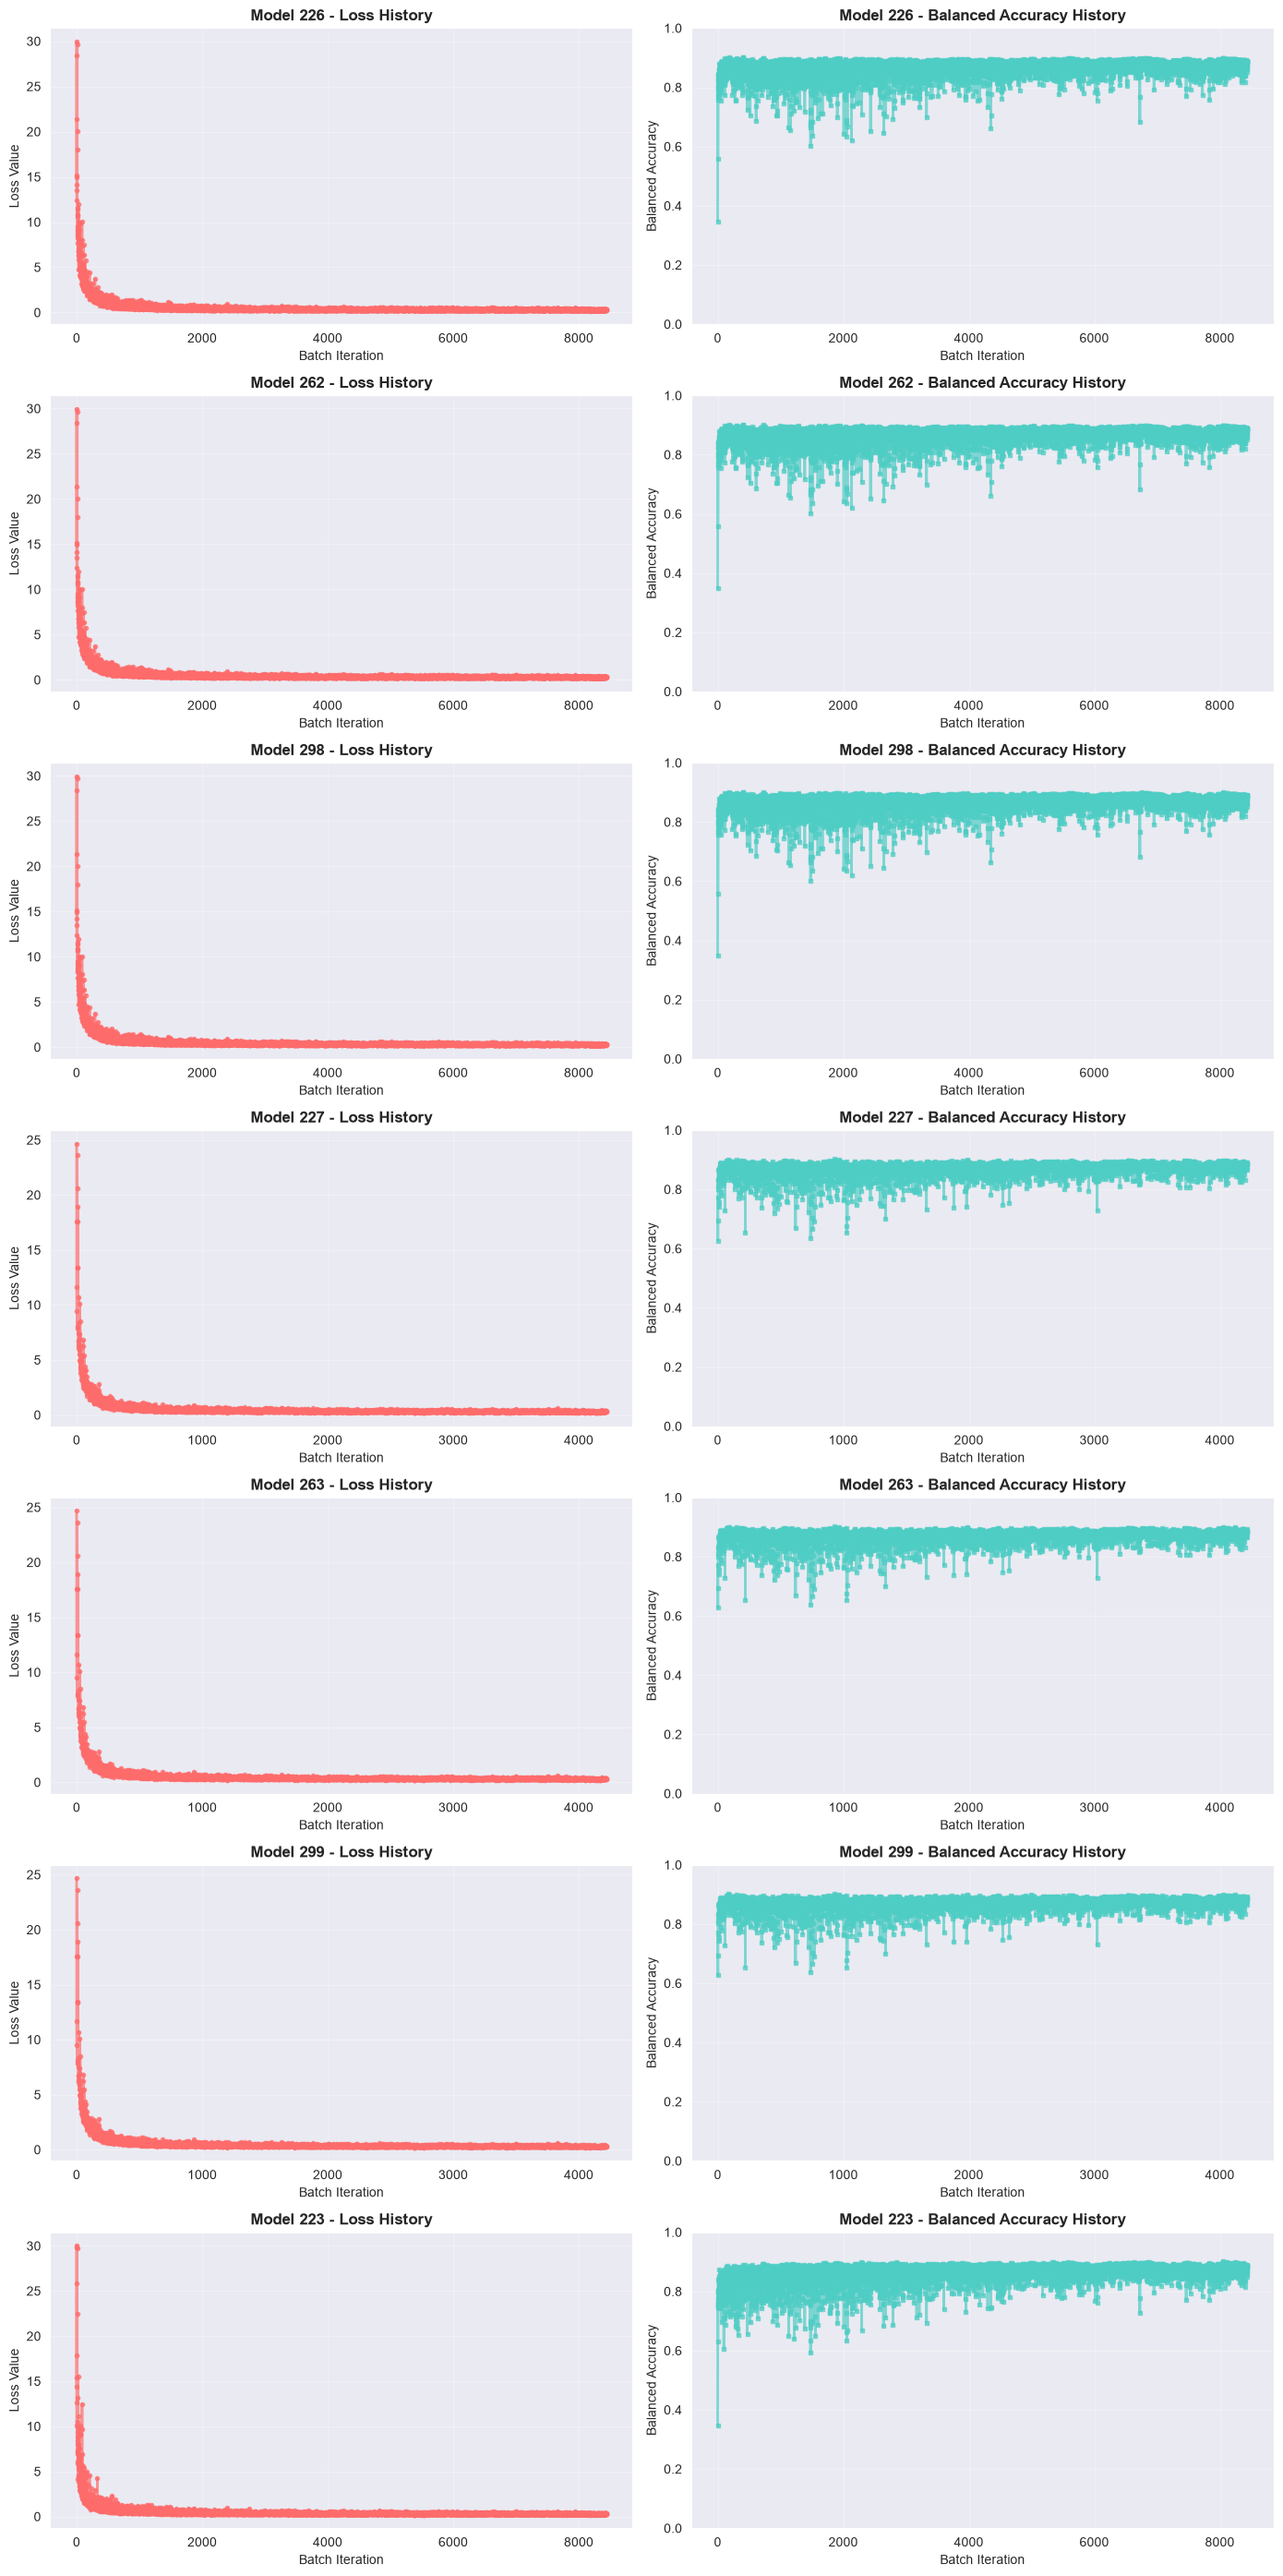

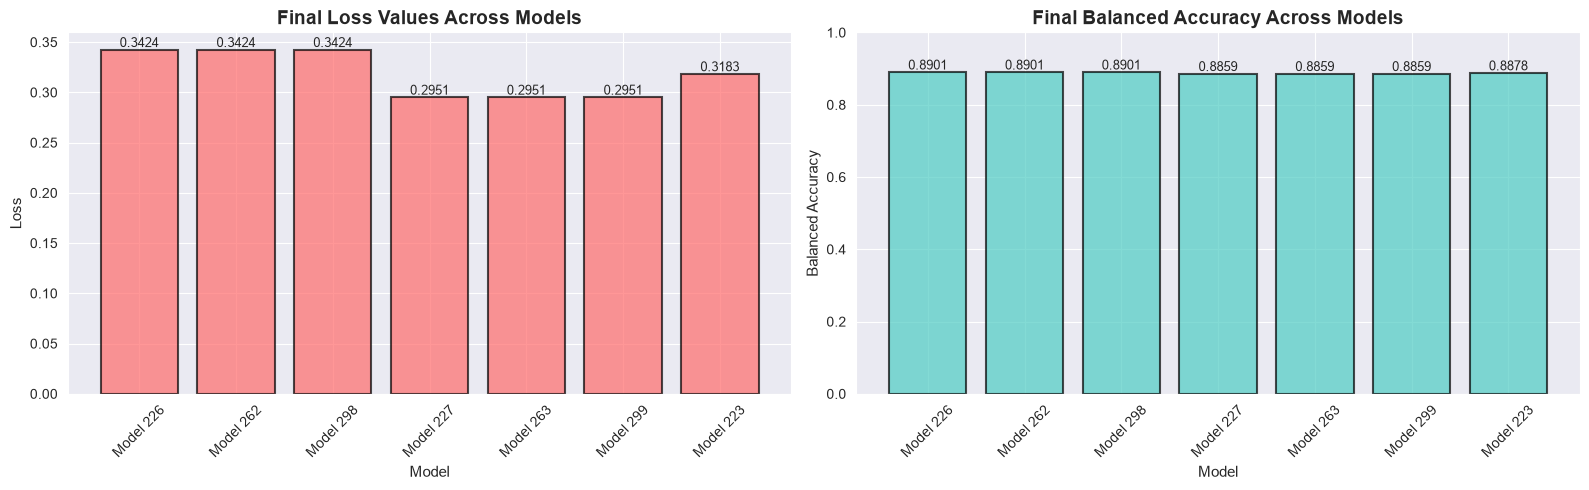


SUMMARY STATISTICS

Model 226:
  Loss:      min=0.198088, max=29.957220, final=0.342447
  Bal.Acc:   min=0.347625, max=0.901595, final=0.890102

Model 262:
  Loss:      min=0.198088, max=29.957220, final=0.342447
  Bal.Acc:   min=0.347625, max=0.901595, final=0.890102

Model 298:
  Loss:      min=0.198088, max=29.957220, final=0.342447
  Bal.Acc:   min=0.347625, max=0.901595, final=0.890102

Model 227:
  Loss:      min=0.202426, max=24.667761, final=0.295065
  Bal.Acc:   min=0.626984, max=0.902438, final=0.885888

Model 263:
  Loss:      min=0.202426, max=24.667761, final=0.295065
  Bal.Acc:   min=0.626984, max=0.902438, final=0.885888

Model 299:
  Loss:      min=0.202426, max=24.667761, final=0.295065
  Bal.Acc:   min=0.626984, max=0.902438, final=0.885888

Model 223:
  Loss:      min=0.199111, max=30.026812, final=0.318334
  Bal.Acc:   min=0.345619, max=0.900558, final=0.887830


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (16, 10)

fig, axes = plt.subplots(amount_of_best_models, 2, figsize=(14, 4*amount_of_best_models))

if amount_of_best_models == 1:
    axes = axes.reshape(1, -1)

model_labels = [f"Model {num}" for num in model_numbers]

for idx in range(amount_of_best_models):
    axes[idx, 0].plot(all_loss_hist[idx], linewidth=2, color='#FF6B6B', marker='o', markersize=3, alpha=0.7)
    axes[idx, 0].set_title(f'{model_labels[idx]} - Loss History', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('Batch Iteration', fontsize=10)
    axes[idx, 0].set_ylabel('Loss Value', fontsize=10)
    axes[idx, 0].grid(True, alpha=0.3)
    
    axes[idx, 1].plot(all_metr_hist[idx], linewidth=2, color='#4ECDC4', marker='s', markersize=3, alpha=0.7)
    axes[idx, 1].set_title(f'{model_labels[idx]} - Balanced Accuracy History', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel('Batch Iteration', fontsize=10)
    axes[idx, 1].set_ylabel('Balanced Accuracy', fontsize=10)
    axes[idx, 1].set_ylim([0, 1])  # Metric from 0 to 1
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

final_losses = [all_loss_hist[i][-1] if all_loss_hist[i] else 0 for i in range(amount_of_best_models)]
ax1.bar(model_labels, final_losses, color='#FF6B6B', alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_title('Final Loss Values Across Models', fontsize=14, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_xlabel('Model', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(final_losses):
    ax1.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

final_metrics = [all_metr_hist[i][-1] if all_metr_hist[i] else 0 for i in range(amount_of_best_models)]
ax2.bar(model_labels, final_metrics, color='#4ECDC4', alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_title('Final Balanced Accuracy Across Models', fontsize=14, fontweight='bold')
ax2.set_ylabel('Balanced Accuracy', fontsize=11)
ax2.set_xlabel('Model', fontsize=11)
ax2.set_ylim([0, 1])
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(final_metrics):
    ax2.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
for idx, model_label in enumerate(model_labels):
    min_loss = min(all_loss_hist[idx]) if all_loss_hist[idx] else 0
    max_loss = max(all_loss_hist[idx]) if all_loss_hist[idx] else 0
    final_loss = all_loss_hist[idx][-1] if all_loss_hist[idx] else 0
    
    min_metr = min(all_metr_hist[idx]) if all_metr_hist[idx] else 0
    max_metr = max(all_metr_hist[idx]) if all_metr_hist[idx] else 0
    final_metr = all_metr_hist[idx][-1] if all_metr_hist[idx] else 0
    
    print(f"\n{model_label}:")
    print(f"  Loss:      min={min_loss:.6f}, max={max_loss:.6f}, final={final_loss:.6f}")
    print(f"  Bal.Acc:   min={min_metr:.6f}, max={max_metr:.6f}, final={final_metr:.6f}")


In [5]:
for ind, i in enumerate(model_numbers):
    print(f"{i}: mean_bal_acc={np.mean(all_metr_hist[ind])}")

226: mean_bal_acc=0.8653571013335584
262: mean_bal_acc=0.8653571013335584
298: mean_bal_acc=0.8653571013335584
227: mean_bal_acc=0.8659575987547251
263: mean_bal_acc=0.8659575987547251
299: mean_bal_acc=0.8659575987547251
223: mean_bal_acc=0.8616227476478071


### Models 227, 263, 299 showed the best target metric

Next, we train the models on the full dataset and obtain predictions for the test set

In [1]:
import pandas as pd
import numpy as np
from data_preprocessing import DataProcessing
from sklearn.linear_model import SGDClassifier
from log_parser import find_best_models, param_parser_by_num
import os


FileName = "logs_log_reg/big_training_log_20260723_230607.log"
DirNameSubm = "submission"
if not os.path.exists(DirNameSubm):
    os.makedirs(DirNameSubm)
amount_of_best_models = 10
reverse_dict = {v: k for k, v in DataProcessing.get_translate_dict().items()}

num_of_best_models = [x[0] for x in find_best_models(FileName, amount_of_best_models)]
params = param_parser_by_num(FileName, num_of_best_models)

model_numbers = [227, 263, 299] # selected best models
amount_of_best_models = len(model_numbers)
FINAL_BEST_MODELS = {num: params[num] for num in model_numbers}

df = pd.read_csv("datasets/train.csv")
y = df["health_condition"]

df_test = pd.read_csv("datasets/test.csv")
id_test = df_test["id"]
                               
train_data_prep = DataProcessing(df, data_type="train")
test_data_prep = DataProcessing(df_test, data_type="test")

train_df = train_data_prep.df_prepr()
X_train = train_df.drop(columns=["health_condition"])
y_train = train_df["health_condition"]

test_data_prep.median = train_data_prep.median
test_data_prep.encoder = train_data_prep.encoder
test_data_prep.scaler = train_data_prep.scaler
test_df = test_data_prep.df_prepr()
X_test = test_df

ind = 0
for model_num, params_for_one in FINAL_BEST_MODELS.items():
    batch_size = params_for_one.pop("batch_size")
    
    class_weight = dict(zip(
        np.unique(y_train), 
        y_train.shape[0] / (len(np.unique(y_train)) * np.bincount(y_train))
    ))
    
    model = SGDClassifier(**params_for_one, class_weight=class_weight)
    
    n_batches = int(np.ceil(len(X_train) / batch_size))

    for i in range(n_batches):
        start = i * batch_size
        end = min((i + 1) * batch_size, len(X_train))
        X_batch = X_train.iloc[start:end]  
        y_batch = y_train.iloc[start:end]
        model.partial_fit(X_batch, y_batch, classes=np.unique(y_train))

    y_pred = np.array([reverse_dict[i] for i in model.predict(X_test)])
    path_name = DirNameSubm+f"/model_num-{model_num}.csv"
    submission = pd.DataFrame({"health_condition": y_pred}, index=id_test)
    submission.to_csv(path_name)
    
    
    




Column sleep_duration: 0
Column heart_rate: 0
Column bmi: 0
Column calorie_expenditure: 0
Column step_count: 0
Column exercise_duration: 0
Column water_intake: 0
Column diet_type: 0
Column stress_level: 0
Column sleep_quality: 0
Column physical_activity_level: 0
Column smoking_alcohol: 0
Column gender: 0
